# cable Workflow

推荐入口 notebook：选择一个主配置 JSON 和一个扫描模板 JSON，运行 `cable` compare，保存结果，并完成汇总与单 case 钻取。


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "examples" / "neuron_compare" / "cable" / "workflow_api.py").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


REPO_ROOT = find_repo_root()
CABLE_ROOT = REPO_ROOT / "examples" / "neuron_compare" / "cable"
if str(CABLE_ROOT) not in sys.path:
    sys.path.insert(0, str(CABLE_ROOT))

import workflow_api


ERROR:2026-04-19 13:32:02,304:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/braincell/examples/neuron_compare/cable/templates/run.py", line 10, in <module>
    from .compare import compare_case
ImportError: attempted relative import with no known parent package

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/swl/braincell/examples/neuron_compare/cable/templates/compare.py", line 12, in <module>
    from .braincell_runner import run_case as run_braincell_case
ImportError: attempted relative import with no known parent package

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File 

## Parameters

这里只手动设置主配置路径和模板路径。主配置只负责模板列表；模板只描述一个 `base + group`。


In [2]:
config_path = CABLE_ROOT / "configs" / "cable_demo.json"
template_path = CABLE_ROOT / "scan_templates" / "io_dc_smoke_v1.json"
out_dir = None
plot_cases = True
expand_only = False
raise_on_failure = True
selected_case_id = None


## Input Preview

In [3]:
inputs = workflow_api.load_workflow_inputs(config_path, template_path)
print("config_path:", inputs["config_path"])
print("template_path:", inputs["template_path"])
print("config_name:", inputs["config_name"])
print("template_name:", inputs["template_name"])
print("run_id:", inputs["run_id"])
print("group_id:", inputs["group_id"])
print("default_out_dir:", inputs["default_out_dir"])
print("n_expanded_cases:", inputs["n_expanded_cases"])
print()
print(json.dumps(inputs["normalized_config"], indent=2, ensure_ascii=False))


config_path: /home/swl/braincell/examples/neuron_compare/cable/configs/cable_demo.json
template_path: /home/swl/braincell/examples/neuron_compare/cable/scan_templates/io_dc_smoke_v1.json
config_name: cable_demo
template_name: io_dc_smoke_v1
run_id: cable_demo__io_dc_smoke_v1
group_id: io_dc_smoke
default_out_dir: /home/swl/braincell/examples/neuron_compare/cable/artifacts/sweeps/cable_demo__io_dc_smoke_v1
n_expanded_cases: 1

{
  "config_id": "cable_demo__io_dc_smoke_v1",
  "config_name": "cable_demo",
  "template_name": "io_dc_smoke_v1",
  "config_path": "/home/swl/braincell/examples/neuron_compare/cable/configs/cable_demo.json",
  "template_path": "/home/swl/braincell/examples/neuron_compare/cable/scan_templates/io_dc_smoke_v1.json",
  "meta": {
    "config": {
      "label": "Cable example sweeps"
    },
    "template": {
      "label": "IO DC smoke"
    }
  },
  "template": {
    "base": {
      "template_family": "multi_compartment_cable",
      "morphology": {
        "kind": "sw

## Run Workflow

In [4]:
run_info = workflow_api.run_notebook_workflow(
    config_path=config_path,
    template_path=template_path,
    out_dir=out_dir,
    plot=plot_cases,
    expand_only=expand_only,
    raise_on_failure=raise_on_failure,
)
tables = workflow_api.build_summary_tables(run_info["out_dir"])

print("status:", run_info["status"])
print("run_id:", run_info["run_id"])
print("out_dir:", run_info["out_dir"])
print(json.dumps(tables["aggregate"], indent=2, ensure_ascii=False))


--No graphics will be displayed.


status: 0
run_id: cable_demo__io_dc_smoke_v1
out_dir: /home/swl/braincell/examples/neuron_compare/cable/artifacts/sweeps/cable_demo__io_dc_smoke_v1
{
  "config_id": "cable_demo__io_dc_smoke_v1",
  "failed_cases": [],
  "n_failed_cases": 0,
  "n_success_cases": 1,
  "n_total_cases": 1,
  "observables": {
    "voltage": {
      "mae_mean": 1.1563612633744192e-09,
      "max_abs_max": 9.487749252912181e-09,
      "n_cases": 1,
      "rel_mae_pct_mean": 1.7823617545886998e-09,
      "rmse_mean": 1.9629464997105863e-09
    }
  },
  "template_family": "multi_compartment_cable"
}


,case_id,group_id,status,stimulus_kind,morphology_kind,morphology_path,dt_ms,cv_per_branch,observable,n_samples,...,morphology.path,simulation.dt_ms,simulation.duration_ms,simulation.v_init_mV,stimulus.amp_nA,stimulus.delay_ms,stimulus.dur_ms,stimulus.kind,stimulus.target,morphology_name
0,io_dc_smoke__000,io_dc_smoke,ok,dc_step,swc,/home/swl/braincell/examples/multi_compartment...,0.025,1,voltage,80,...,/home/swl/braincell/examples/multi_compartment...,0.025,2.0,-65.0,0.05,0.5,1.0,dc_step,root_soma_midpoint,io.swc


,case_id,group_id,status,stimulus_kind,morphology_kind,morphology_path,dt_ms,cv_per_branch,observable,n_samples,...,morphology.path,simulation.dt_ms,simulation.duration_ms,simulation.v_init_mV,stimulus.amp_nA,stimulus.delay_ms,stimulus.dur_ms,stimulus.kind,stimulus.target,morphology_name


,morphology_name,n_rows,n_cases,mae_mean,rmse_mean,max_abs_max,rel_mae_pct_mean
0,io.swc,1,1,1.156361e-09,1.962946e-09,9.487749e-09,1.782362e-09


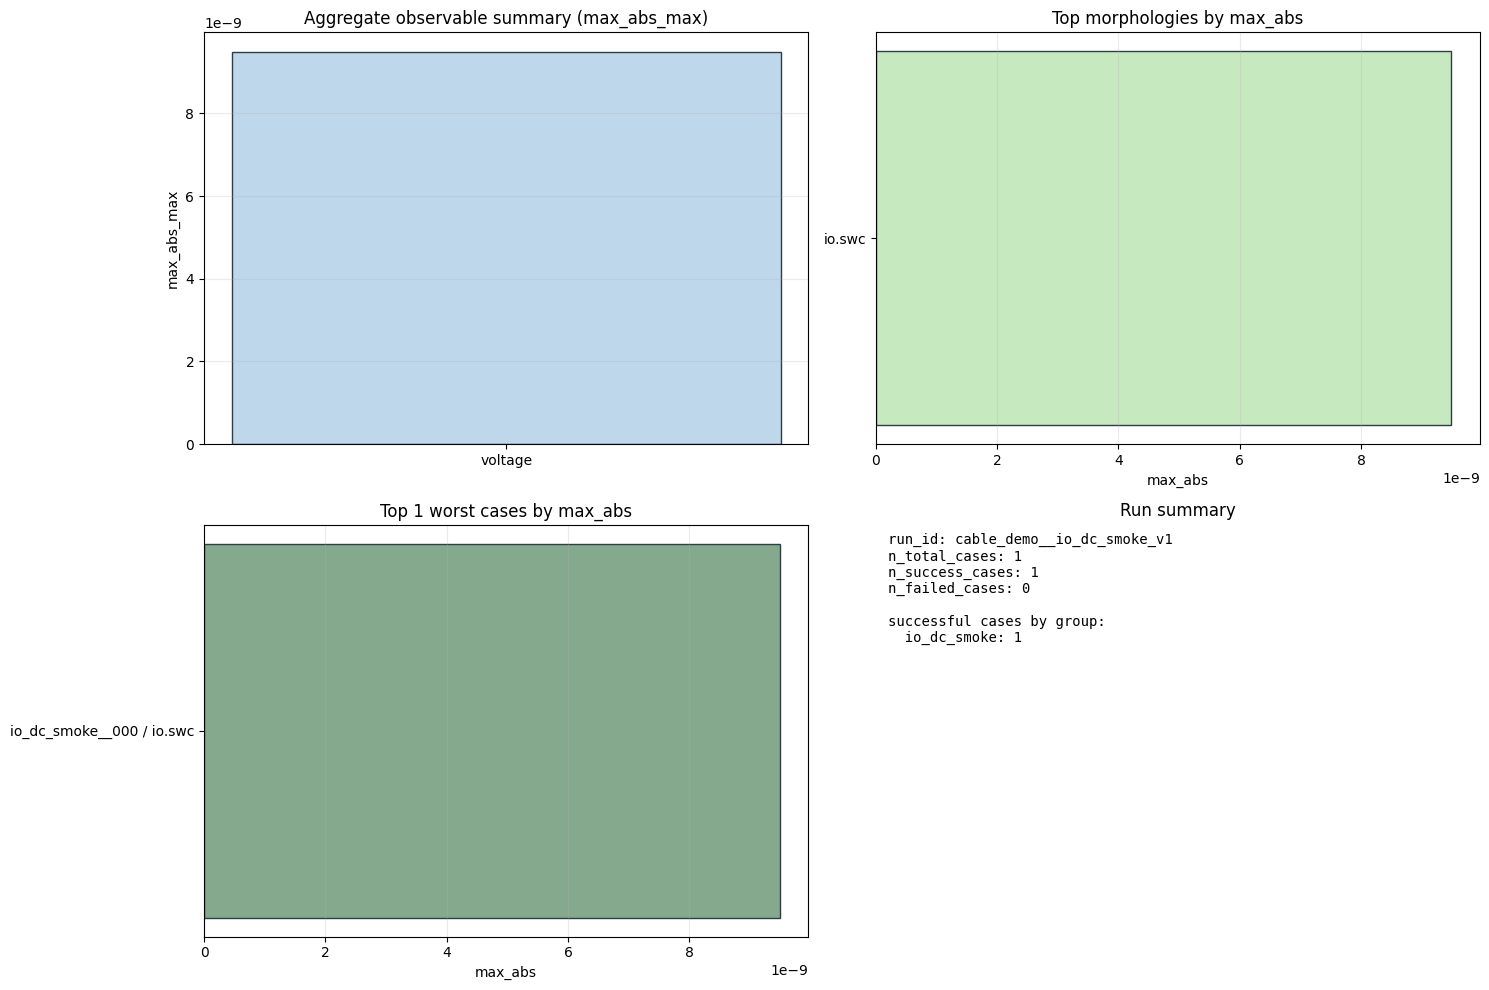

In [5]:
display(tables["worst_cases_df"].head(20))
display(tables["failed_df"])
display(tables["by_morphology_df"])

summary_fig, summary_axes = workflow_api.plot_sweep_summary(tables, metric="max_abs")
plt.show()


selected_case_id: io_dc_smoke__000


,compartment_index,mae,max_abs,rel_mae_pct,rmse,braincell_label,neuron_label,braincell_canonical_name,neuron_canonical_name
0,8,4.586439e-09,9.487749e-09,7.067158e-09,5.751950e-09,dend[2]:cv0,dend[2]:seg0,dend[2],dend[2]
1,11,3.755168e-09,7.654691e-09,5.785509e-09,4.676627e-09,dend[5]:cv0,dend[5]:seg0,dend[5],dend[5]
2,10,3.127903e-09,6.498539e-09,4.818180e-09,4.002702e-09,dend[4]:cv0,dend[4]:seg0,dend[4],dend[4]
3,21,2.796277e-09,5.783193e-09,4.306932e-09,3.615834e-09,dend[15]:cv0,dend[15]:seg0,dend[15],dend[15]
4,20,1.981941e-09,4.185253e-09,3.055065e-09,2.621133e-09,dend[14]:cv0,dend[14]:seg0,dend[14],dend[14]
5,18,1.493654e-09,3.059739e-09,2.301313e-09,1.859730e-09,dend[12]:cv0,dend[12]:seg0,dend[12],dend[12]
6,23,1.245725e-09,2.522199e-09,1.919158e-09,1.546641e-09,dend[17]:cv0,dend[17]:seg0,dend[17],dend[17]
7,30,1.146259e-09,2.418986e-09,1.765322e-09,1.490165e-09,dend[19]:cv0,dend[19]:seg0,dend[19],dend[19]
8,15,1.140563e-09,2.357368e-09,1.757874e-09,1.448536e-09,dend[9]:cv0,dend[9]:seg0,dend[9],dend[9]
9,14,1.086705e-09,2.261729e-09,1.674719e-09,1.385897e-09,dend[8]:cv0,dend[8]:seg0,dend[8],dend[8]


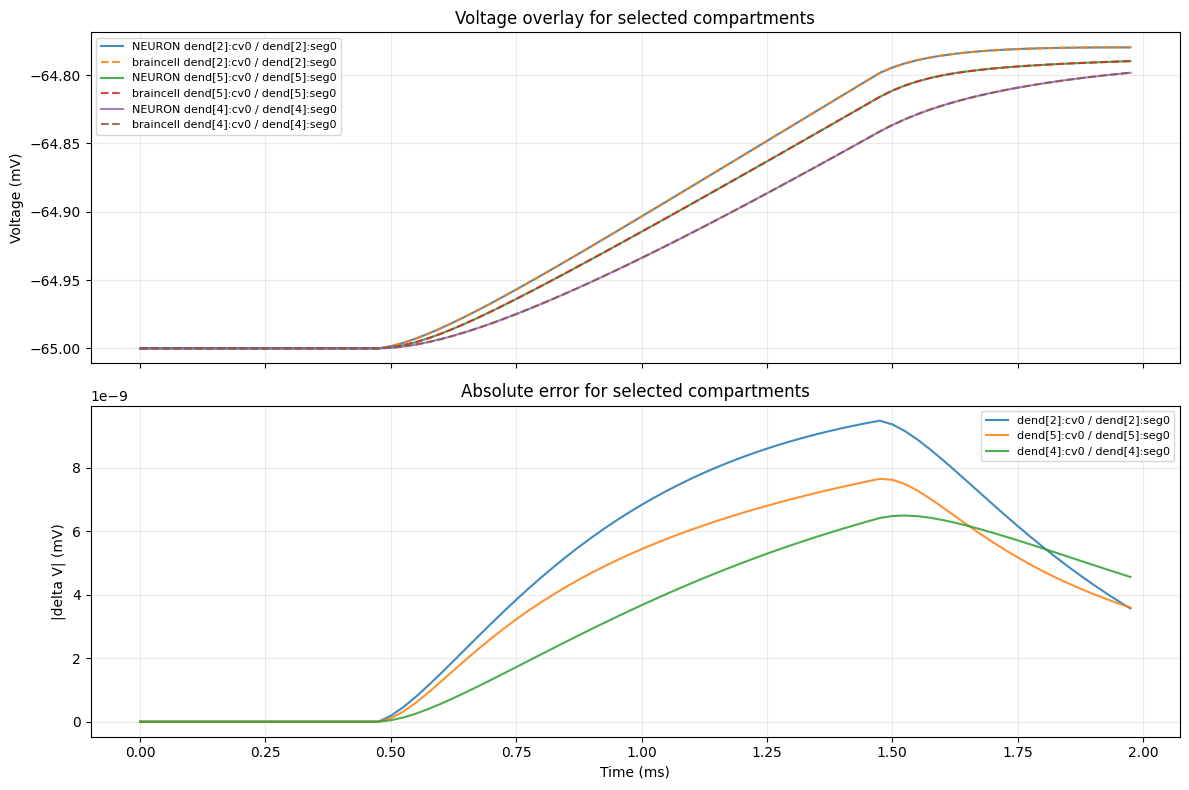

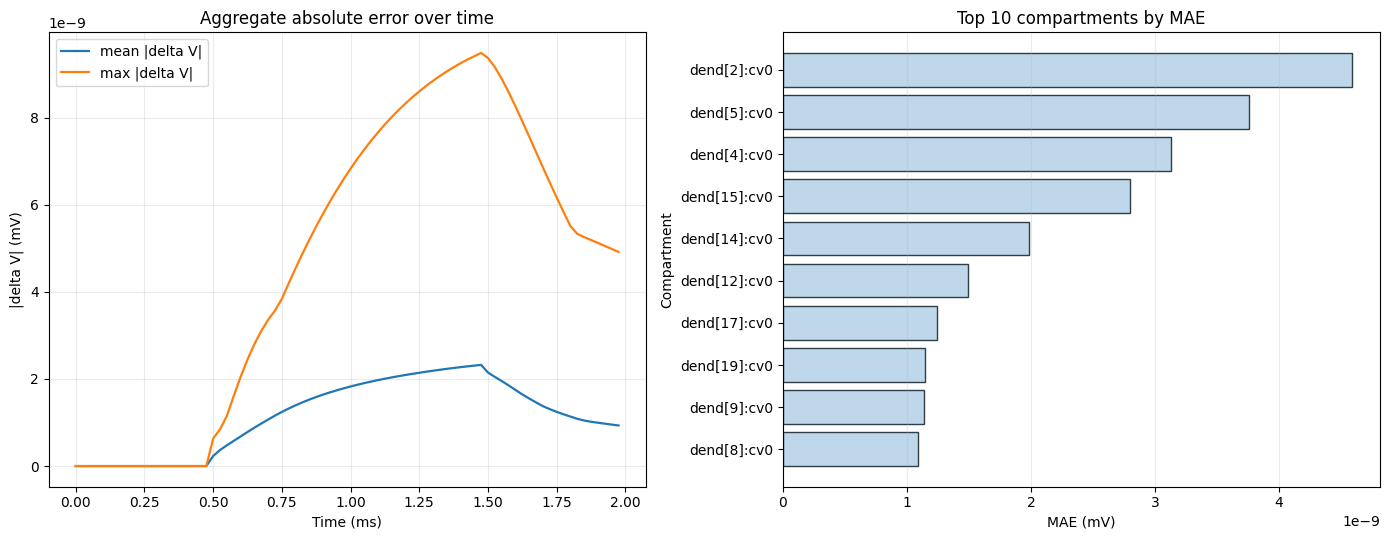

In [6]:
selected_case_id = selected_case_id or (
    tables["worst_cases_df"].iloc[0]["case_id"]
    if not tables["worst_cases_df"].empty
    else None
)
print("selected_case_id:", selected_case_id)

if selected_case_id is not None:
    case_result = workflow_api.load_case_result(run_info["out_dir"], selected_case_id)
    case_metrics_df = workflow_api.build_case_metric_table(case_result)
    display(case_metrics_df.head(15))

    workflow_api.plot_case_overlay(case_result, max_compartments=3)
    plt.show()

    workflow_api.plot_case_error_summary(case_result, top_k=10)
    plt.show()
else:
    print("No successful case available for drill-down.")
